# Laboratorio: Isolation Forest sobre **4 KPIs** unidos (AIOps)

En este notebook unimos **cuatro métricas** del AIOps Challenge 2018 que comparten la misma ventana temporal (~146k puntos, 1 minuto, abr–jul 2017). Cada fila es un instante; cada columna es el `value` de un KPI distinto.

El objetivo es el mismo que en el laboratorio de un solo KPI: entrenar **Isolation Forest** multivariado, interpretar el ranking y comparar hiperparámetros — pero ahora las anomalías son **combinaciones raras entre métricas**, no solo rareza en una serie.

Dataset: [NetManAIOps / KPI-Anomaly-Detection](https://github.com/NetManAIOps/KPI-Anomaly-Detection) (competencia AIOps 2018).


## 0. Dependencias

Solo hace falta lo del bloque de imports. Los datos se descargan por HTTP si no están en `data/`.


In [1]:
# Sin instalaciones extra.


## 1. Imports y configuración

Usamos `pandas` para el join por `timestamp`, `scikit-learn` para Isolation Forest y `StandardScaler` (imprescindible al mezclar KPIs con escalas distintas).


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree

RANDOM_STATE = 42
plt.style.use("default")
pd.set_option("display.max_columns", 40)


## 2. Descargar dataset AIOps KPI

Mismo `phase2_train.csv` que en el laboratorio de un KPI. Tiene **29 KPI IDs**; solo usaremos **cuatro** del grupo “largo” (misma época, timestamps alineables).


In [3]:
import urllib.request
import zipfile

KPI_ZIP_URL = (
    "https://github.com/NetManAIOps/KPI-Anomaly-Detection/raw/master/"
    "Finals_dataset/phase2_train.csv.zip"
)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
kpi_zip_path = DATA_DIR / "phase2_train.csv.zip"
kpi_csv_path = DATA_DIR / "phase2_train.csv"

if not kpi_csv_path.exists():
    print("Descargando AIOps KPI (puede tardar ~30 s)...")
    with urllib.request.urlopen(KPI_ZIP_URL, timeout=120) as resp:
        kpi_zip_path.write_bytes(resp.read())
    with zipfile.ZipFile(kpi_zip_path) as zf:
        zf.extract("phase2_train.csv", path=DATA_DIR)
    print("Guardado en:", kpi_csv_path.resolve())
else:
    print("Usando cache local:", kpi_csv_path.resolve())

kpi_all = pd.read_csv(kpi_csv_path)
kpi_all["timestamp"] = pd.to_datetime(kpi_all["timestamp"], unit="s")

kpi_summary = (
    kpi_all.groupby("KPI ID")
    .agg(
        puntos=("value", "size"),
        desde=("timestamp", "min"),
        hasta=("timestamp", "max"),
    )
    .sort_values("puntos", ascending=False)
)
print(f"KPIs disponibles: {len(kpi_summary)}  |  Filas totales: {len(kpi_all):,}")
kpi_summary.head(10)


Descargando AIOps KPI (puede tardar ~30 s)...


Guardado en: /home/juan/Escritorio/aiops/AIOps/Implementacion K8S/Codigo/notebooks/data/phase2_train.csv


KPIs disponibles: 29  |  Filas totales: 3,004,066


,puntos,desde,hasta
KPI ID,,,
05f10d3a-239c-3bef-9bdc-a2feeb0037aa,146255,2017-04-01 10:08:00,2017-07-14 06:14:00
c69a50cf-ee03-3bd7-831e-407d36c7ee91,146255,2017-04-01 10:08:00,2017-07-14 06:14:00
1c6d7a26-1f1a-3321-bb4d-7a9d969ec8f0,146254,2017-04-01 10:08:00,2017-07-14 06:14:00
adb2fde9-8589-3f5b-a410-5fe14386c7af,146254,2017-04-01 10:08:00,2017-07-14 06:14:00
42d6616d-c9c5-370a-a8ba-17ead74f3114,146253,2017-04-01 10:08:00,2017-07-14 06:14:00
8723f0fb-eaef-32e6-b372-6034c9c04b80,146243,2017-04-01 10:08:00,2017-07-14 06:14:00
6d1114ae-be04-3c46-b5aa-be1a003a57cd,146239,2017-04-01 10:08:00,2017-07-14 06:14:00
847e8ecc-f8d2-3a93-9107-f367a0aab37d,146228,2017-04-01 10:08:00,2017-07-14 06:14:00
55f8b8b8-b659-38df-b3df-e4a5a8a54bc9,146204,2017-04-01 10:08:00,2017-07-14 06:14:00


## 3. Join de 4 KPIs por `timestamp`

Elegimos cuatro IDs del grupo con ~146k puntos (abr–jul 2017). El join es un `pivot`: una fila por minuto, una columna por KPI.

| Alias | KPI ID (primeros 8 chars) |
|-------|---------------------------|
| kpi_a | `05f10d3a...` |
| kpi_b | `c69a50cf...` |
| kpi_c | `1c6d7a26...` |
| kpi_d | `adb2fde9...` |

Usamos `dropna()` (join interno): descartamos minutos donde falte algún KPI. En la práctica pierde muy pocas filas.


In [4]:
KPI_IDS = ['05f10d3a-239c-3bef-9bdc-a2feeb0037aa', 'c69a50cf-ee03-3bd7-831e-407d36c7ee91', '1c6d7a26-1f1a-3321-bb4d-7a9d969ec8f0', 'adb2fde9-8589-3f5b-a410-5fe14386c7af']
SHORT_NAMES = ['kpi_a', 'kpi_b', 'kpi_c', 'kpi_d']
ID_TO_SHORT = dict(zip(KPI_IDS, SHORT_NAMES))

subset = kpi_all[kpi_all["KPI ID"].isin(KPI_IDS)].copy()
wide = (
    subset.pivot(index="timestamp", columns="KPI ID", values="value")
    .sort_index()
    .rename(columns=ID_TO_SHORT)
    .reset_index()
)
raw = wide.dropna().reset_index(drop=True)

print("Filas despues del join:", len(raw))
print("Columnas KPI:", SHORT_NAMES)
print(f"Desde {raw['timestamp'].min()} hasta {raw['timestamp'].max()}")
raw[SHORT_NAMES].describe().T


Filas despues del join: 146253
Columnas KPI: ['kpi_a', 'kpi_b', 'kpi_c', 'kpi_d']
Desde 2017-04-01 10:08:00 hasta 2017-07-14 06:14:00


,count,mean,std,min,25%,50%,75%,max
KPI ID,,,,,,,,
kpi_a,146253.0,34.438926,4.203548,0.0,31.55,34.15,36.84,98.33
kpi_b,146253.0,35.048789,5.692431,1.5,32.11,34.80,37.40,172.19
kpi_c,146253.0,35.539637,5.729775,1.7,32.59,35.30,37.95,172.42
kpi_d,146253.0,34.188606,5.287161,0.0,31.37,34.02,36.69,119.77


## 4. Primera mirada

Cuatro series en paralelo. Las escalas suelen diferir (el CSV no trae nombres legibles de métrica); por eso luego **estandarizamos** antes del IF.


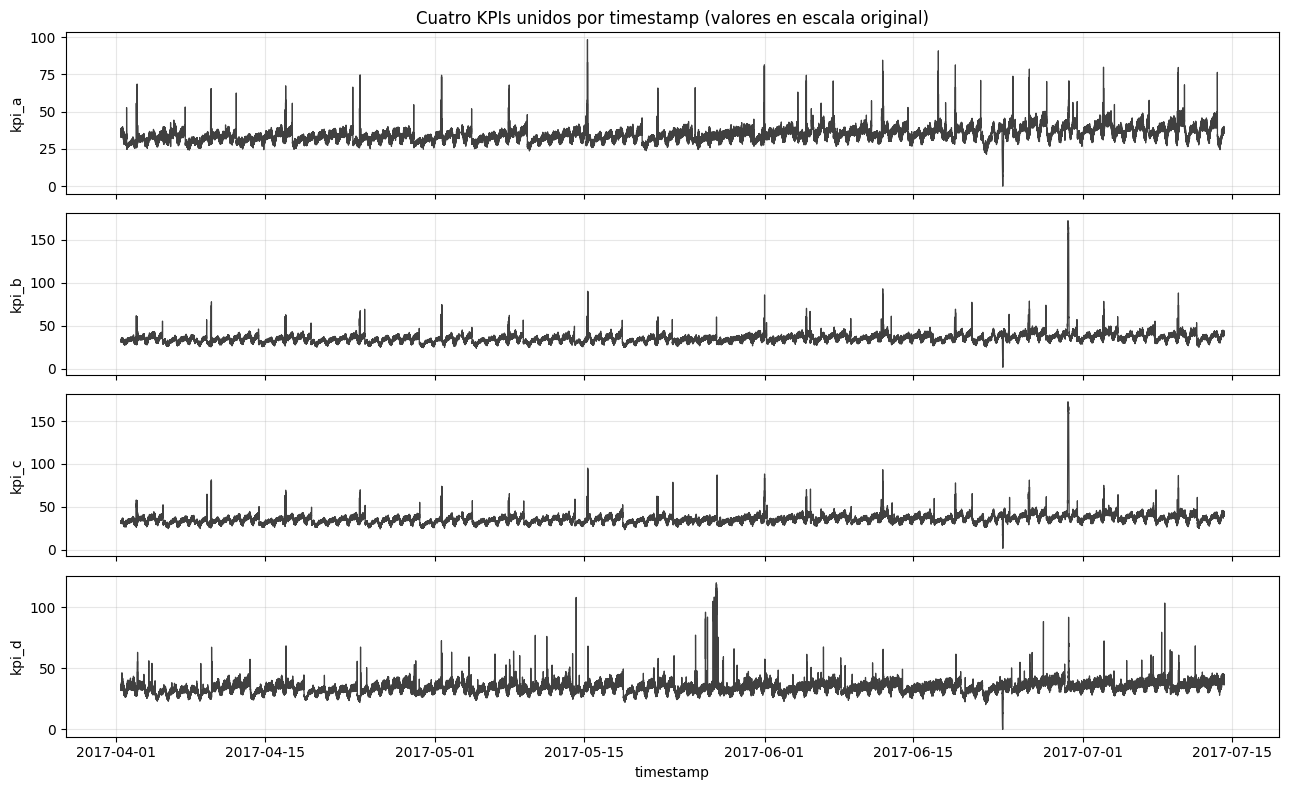

In [5]:
fig, axes = plt.subplots(len(SHORT_NAMES), 1, figsize=(13, 8), sharex=True)

for ax, name in zip(axes, SHORT_NAMES):
    ax.plot(raw["timestamp"], raw[name], color="0.25", linewidth=0.9)
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Cuatro KPIs unidos por timestamp (valores en escala original)")
axes[-1].set_xlabel("timestamp")
plt.tight_layout()
plt.show()


## 5. Construcción de features

Por cada KPI calculamos `value`, `diff_1` y `rolling_z` (ventana 12). Agregamos `hour` y `dayofweek` compartidos.

En total: 4 × 3 + 2 = **14 features** para el Isolation Forest multivariado.


### Qué es `rolling_z` (z-score móvil)

Para cada KPI, compara el valor actual con la media y el desvío de los últimos 12 minutos. Un pico en **una** métrica con las demás normales puede ser anómalo a nivel sistema.


In [6]:
def build_features_multikpi(df: pd.DataFrame, kpi_cols: list[str], window: int = 12) -> pd.DataFrame:
    data = df.copy()
    data["timestamp"] = pd.to_datetime(data["timestamp"])
    data = data.sort_values("timestamp").reset_index(drop=True)

    features = pd.DataFrame({"timestamp": data["timestamp"]})
    for col in kpi_cols:
        y = data[col].astype(float)
        features[col] = y
        features[f"{col}_diff_1"] = y.diff()
        roll_mean = y.rolling(window, min_periods=3).mean()
        roll_std = y.rolling(window, min_periods=3).std()
        features[f"{col}_rolling_z"] = (y - roll_mean) / roll_std.replace(0, np.nan)

    features["hour"] = features["timestamp"].dt.hour
    features["dayofweek"] = features["timestamp"].dt.dayofweek
    return features.dropna().reset_index(drop=True)


features = build_features_multikpi(raw, SHORT_NAMES, window=12)
features.head()


,timestamp,kpi_a,kpi_a_diff_1,kpi_a_rolling_z,kpi_b,kpi_b_diff_1,kpi_b_rolling_z,kpi_c,kpi_c_diff_1,kpi_c_rolling_z,kpi_d,kpi_d_diff_1,kpi_d_rolling_z,hour,dayofweek
0,2017-04-01 10:10:00,32.79,-3.81,-1.053203,33.06,0.86,0.992339,31.82,-0.43,-0.810026,34.40,1.41,0.359050,10,5
1,2017-04-01 10:11:00,34.28,1.49,-0.249142,32.35,-0.71,0.169385,32.94,1.12,0.437932,33.53,-0.87,-0.486341,10,5
2,2017-04-01 10:12:00,34.69,0.41,0.008740,32.69,0.34,0.560960,33.20,0.26,0.678454,35.45,1.92,1.240136,10,5
3,2017-04-01 10:13:00,35.30,0.61,0.413320,32.27,-0.42,-0.070585,32.70,-0.50,-0.049029,32.96,-2.49,-1.038737,10,5
4,2017-04-01 10:14:00,35.25,-0.05,0.346534,32.77,0.50,0.694057,32.55,-0.15,-0.274189,33.44,0.48,-0.519478,10,5


## 6. Matriz de entrenamiento

Mezclamos KPIs con unidades distintas → `StandardScaler` sobre todas las columnas numéricas.


In [7]:
feature_cols = ['kpi_a', 'kpi_a_diff_1', 'kpi_a_rolling_z', 'kpi_b', 'kpi_b_diff_1', 'kpi_b_rolling_z', 'kpi_c', 'kpi_c_diff_1', 'kpi_c_rolling_z', 'kpi_d', 'kpi_d_diff_1', 'kpi_d_rolling_z', 'hour', 'dayofweek']

X = features[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Filas para entrenar:", X.shape[0])
print("N features:", len(feature_cols))


Filas para entrenar: 146218
N features: 14


## 7. Entrenar Isolation Forest

Parámetros principales (se fijan **al crear y entrenar** el modelo con `fit()`):

- `n_estimators = m`: cantidad de árboles.
- `max_samples = ψ`: tamaño de submuestra por árbol.
- `contamination`: proporción del ranking que se etiqueta como anomalía.

Entrenamos **tres configuraciones** sobre la misma matriz para comparar cómo cambian las etiquetas.


In [8]:
psi = min(256, len(features))

MODEL_CONFIGS = [
    {"name": "base", "label": "base (m=200, contamination=2%)", "m": 200, "contamination": 0.02},
    {"name": "pocas_alertas", "label": "pocas alertas (m=200, contamination=0.5%)", "m": 200, "contamination": 0.005},
    {"name": "pocos_arboles", "label": "pocos arboles (m=50, contamination=2%)", "m": 50, "contamination": 0.02},
]


def fit_isolation_forest(X_scaled, m, psi, contamination):
    clf = IsolationForest(
        n_estimators=m,
        max_samples=psi,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )
    pred = clf.fit_predict(X_scaled)
    scores = -clf.score_samples(X_scaled)
    return clf, scores, pred == -1


models = {}
for cfg in MODEL_CONFIGS:
    clf, scores, flags = fit_isolation_forest(
        X_scaled, cfg["m"], psi, cfg["contamination"]
    )
    models[cfg["name"]] = {
        "model": clf,
        "label": cfg["label"],
        "m": cfg["m"],
        "contamination": cfg["contamination"],
        "anomaly_score": scores,
        "is_anomaly": flags,
    }

base = models["base"]
model = base["model"]
m = base["m"]
contamination = base["contamination"]

results = features.copy()
results["anomaly_score"] = base["anomaly_score"]
results["is_anomaly"] = base["is_anomaly"]
for cfg in MODEL_CONFIGS:
    if cfg["name"] == "base":
        continue
    results[f"is_anomaly_{cfg['name']}"] = models[cfg["name"]]["is_anomaly"]

# Promedio de valores (solo para graficos; el IF usa todas las features)
results["value_mean"] = results[SHORT_NAMES].mean(axis=1)

comparison_rows = []
for cfg in MODEL_CONFIGS:
    if cfg["name"] == "base":
        continue
    flags = models[cfg["name"]]["is_anomaly"]
    comparison_rows.append(
        {
            "config": cfg["name"],
            "m": cfg["m"],
            "contamination": cfg["contamination"],
            "n_anomalies": int(flags.sum()),
            "overlap_con_base": int((flags & base["is_anomaly"]).sum()),
            "pct_etiquetas_distintas": round(100 * (flags != base["is_anomaly"]).mean(), 2),
        }
    )

display(pd.DataFrame(comparison_rows))
results[["timestamp", "value_mean", "anomaly_score", "is_anomaly"]].head()


,config,m,contamination,n_anomalies,overlap_con_base,pct_etiquetas_distintas
0,pocas_alertas,200,0.005,732,732,1.5
1,pocos_arboles,50,0.020,2925,2191,1.0


,timestamp,value_mean,anomaly_score,is_anomaly
0,2017-04-01 10:10:00,33.0175,0.437429,False
1,2017-04-01 10:11:00,33.2750,0.400240,False
2,2017-04-01 10:12:00,34.0075,0.405431,False
3,2017-04-01 10:13:00,33.3075,0.401374,False
4,2017-04-01 10:14:00,33.5025,0.391956,False


### Comparar las tres configuraciones

Misma matriz multivariada: `contamination` cambia **cuántos** puntos se etiquetan; `m` distinto con `contamination` fijo cambia **cuáles**.


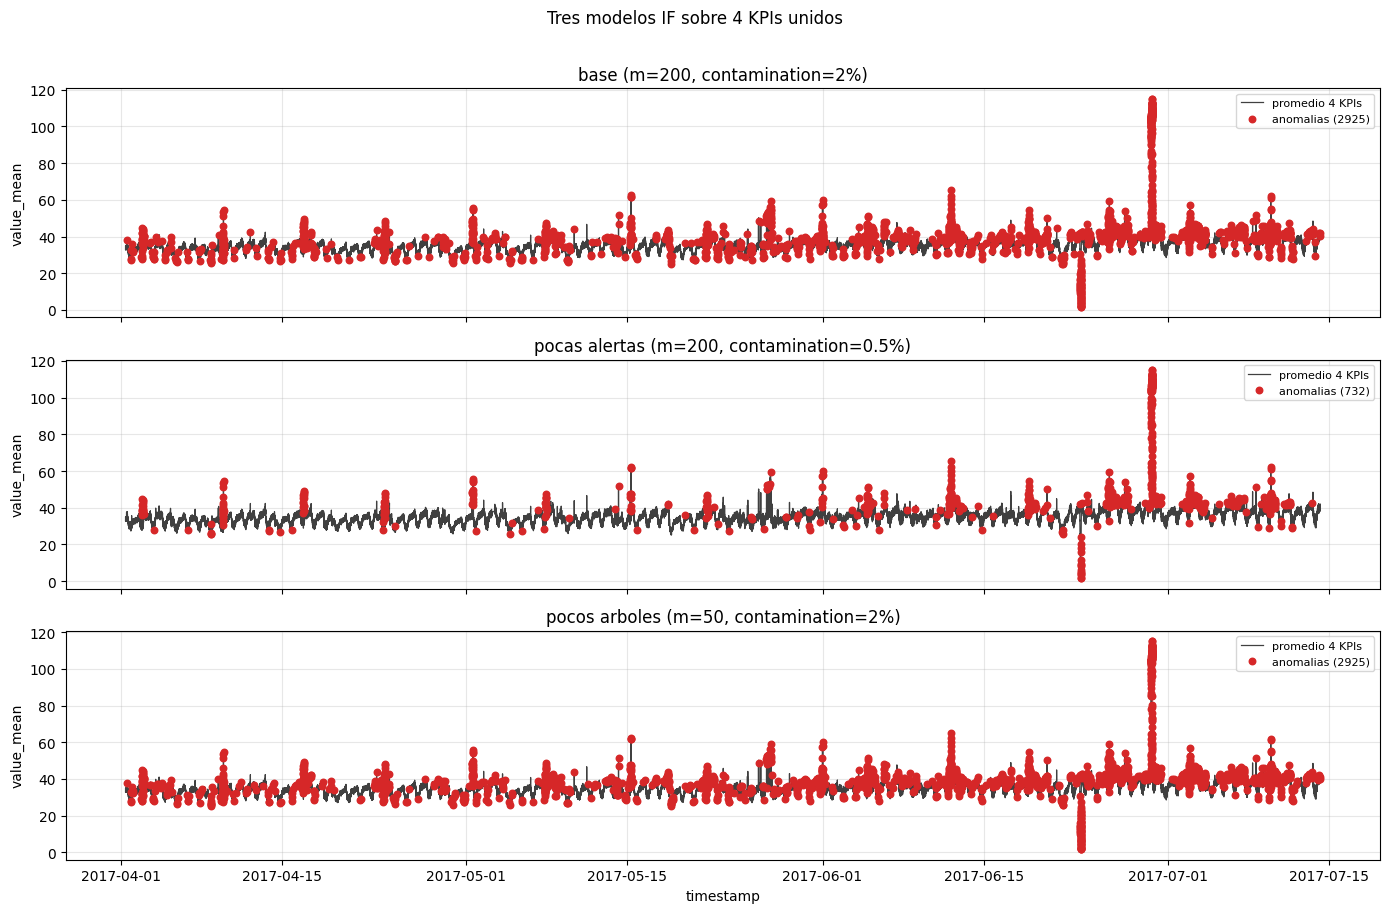

In [9]:
fig, axes = plt.subplots(len(MODEL_CONFIGS), 1, figsize=(14, 9), sharex=True)

for ax, cfg in zip(axes, MODEL_CONFIGS):
    flags = models[cfg["name"]]["is_anomaly"]
    n_flags = int(flags.sum())
    ax.plot(results["timestamp"], results["value_mean"], color="0.25", linewidth=0.9, label="promedio 4 KPIs")
    ax.scatter(
        results.loc[flags, "timestamp"],
        results.loc[flags, "value_mean"],
        color="tab:red",
        s=22,
        zorder=3,
        label=f"anomalias ({n_flags})",
    )
    ax.set_title(cfg["label"])
    ax.set_ylabel("value_mean")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("timestamp")
fig.suptitle("Tres modelos IF sobre 4 KPIs unidos", y=1.01)
plt.tight_layout()
plt.show()


## 8. Resultados: ranking y visualización

Top anomalías con los valores de los cuatro KPIs en ese minuto.


In [10]:
display_cols = ["timestamp", "anomaly_score", "is_anomaly"] + ['kpi_a', 'kpi_b', 'kpi_c', 'kpi_d']
top_anomalies = results.sort_values("anomaly_score", ascending=False).head(15)
top_anomalies[display_cols]


,timestamp,anomaly_score,is_anomaly,kpi_a,kpi_b,kpi_c,kpi_d
120740,2017-06-25 20:12:00,0.678442,True,37.26,61.83,65.02,36.06
126014,2017-06-29 15:09:00,0.674825,True,55.35,146.94,147.01,71.64
126007,2017-06-29 15:02:00,0.670290,True,49.76,155.13,155.62,87.64
126020,2017-06-29 15:16:00,0.669649,True,63.21,152.65,154.01,65.60
101655,2017-06-12 03:06:00,0.666023,True,38.68,58.53,60.55,62.97
126025,2017-06-29 15:21:00,0.662031,True,53.37,112.74,113.04,61.55
140322,2017-07-09 23:06:00,0.661665,True,38.08,78.59,79.30,48.54
126026,2017-06-29 15:22:00,0.660020,True,51.93,95.90,95.07,59.90
126023,2017-06-29 15:19:00,0.655052,True,53.51,138.60,137.54,65.05
101656,2017-06-12 03:07:00,0.654945,True,36.07,92.85,93.29,38.93


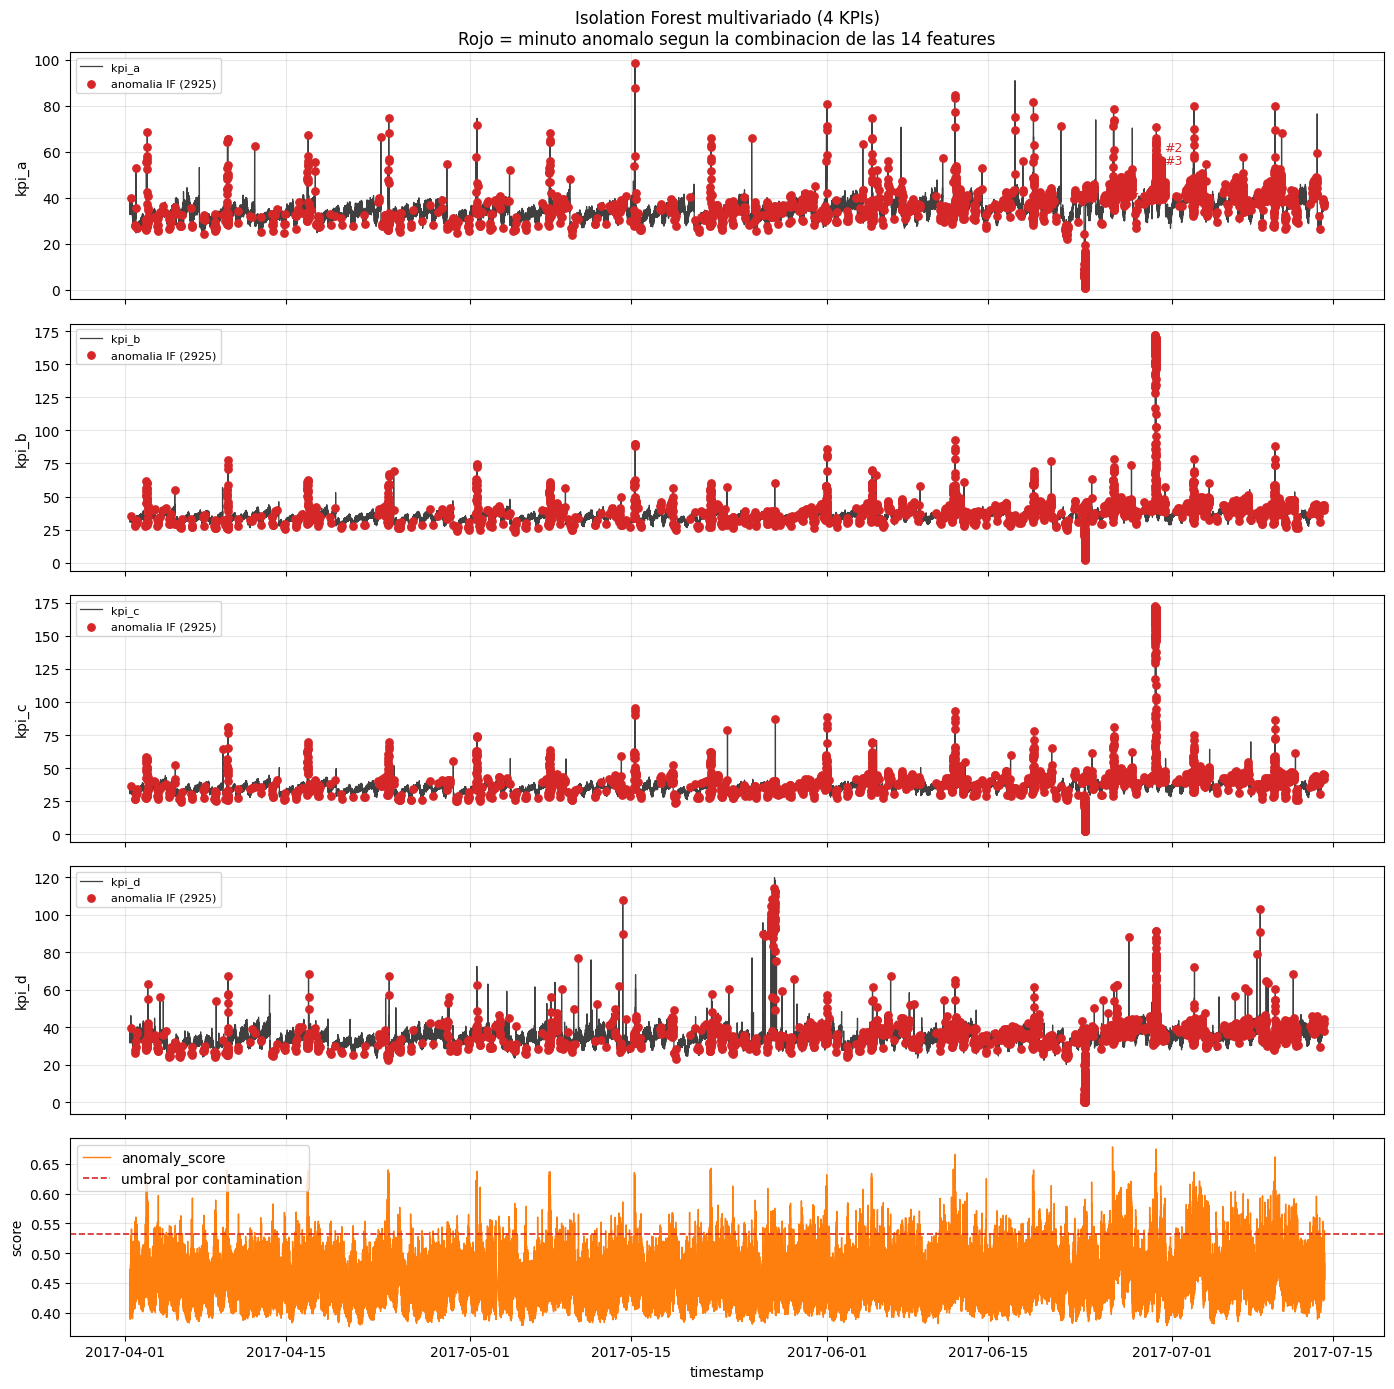

In [11]:
def annotate_top_points(ax, data, y_col, score_col="anomaly_score", n=3):
    top = data.sort_values(score_col, ascending=False).head(n)
    for rank, (_, row) in enumerate(top.iterrows(), start=1):
        ax.annotate(
            f"#{rank}",
            xy=(row["timestamp"], row[y_col]),
            xytext=(6, 8),
            textcoords="offset points",
            fontsize=9,
            color="tab:red",
            arrowprops={"arrowstyle": "->", "color": "tab:red", "lw": 0.8},
        )


threshold = results.loc[results["is_anomaly"], "anomaly_score"].min()
n_anomalies = int(results["is_anomaly"].sum())

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True, gridspec_kw={"height_ratios": [1.5, 1.5, 1.5, 1.5, 1.2]})

for ax, name in zip(axes[:4], SHORT_NAMES):
    ax.plot(results["timestamp"], results[name], linewidth=0.9, color="0.25", label=name)
    ax.scatter(
        results.loc[results["is_anomaly"], "timestamp"],
        results.loc[results["is_anomaly"], name],
        color="tab:red",
        s=28,
        zorder=3,
        label=f"anomalia IF ({n_anomalies})",
    )
    if name == SHORT_NAMES[0]:
        annotate_top_points(ax, results, y_col=name, n=3)
    ax.set_ylabel(name)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title(
    "Isolation Forest multivariado (4 KPIs)\n"
    "Rojo = minuto anomalo segun la combinacion de las 14 features"
)

ax = axes[4]
ax.plot(results["timestamp"], results["anomaly_score"], linewidth=1, color="tab:orange", label="anomaly_score")
ax.axhline(threshold, color="tab:red", linestyle="--", linewidth=1.2, label="umbral por contamination")
ax.fill_between(
    results["timestamp"],
    threshold,
    results["anomaly_score"],
    where=results["anomaly_score"] >= threshold,
    color="tab:red",
    alpha=0.15,
    interpolate=True,
)
ax.set_ylabel("score")
ax.set_xlabel("timestamp")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Visualizar un iTree

Proyectamos en 2D: `kpi_a` vs `kpi_b` (estandarizados). El árbol particiona el plano según **combinaciones** de ambas métricas.


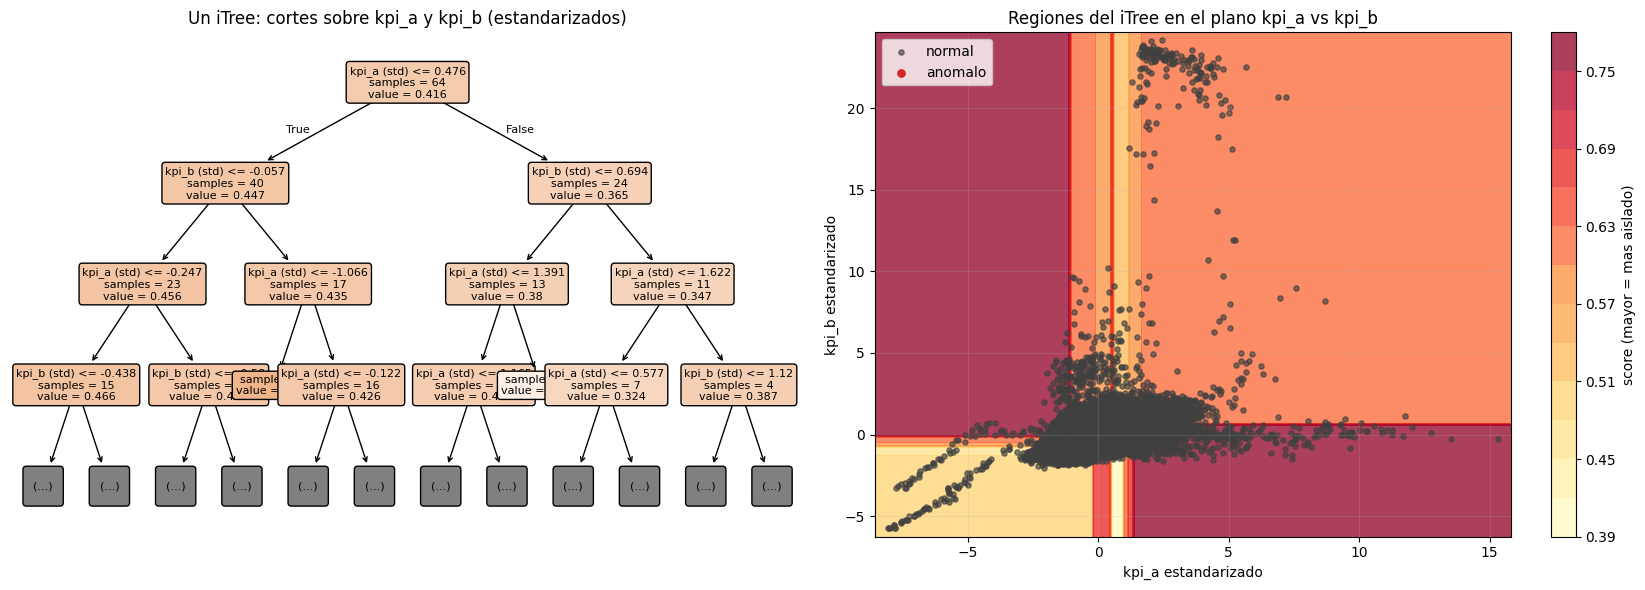

In [12]:
tree_cols = ["kpi_a", "kpi_b"]
X_tree_raw = results[tree_cols]
tree_scaler = StandardScaler()
X_tree = tree_scaler.fit_transform(X_tree_raw)

one_tree_if = IsolationForest(
    n_estimators=1,
    max_samples=min(64, len(results)),
    contamination=contamination,
    random_state=7,
)
one_tree_if.fit(X_tree)
one_tree_pred = one_tree_if.predict(X_tree) == -1
single_tree = one_tree_if.estimators_[0]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

plot_tree(
    single_tree,
    max_depth=3,
    feature_names=["kpi_a (std)", "kpi_b (std)"],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
    ax=axes[0],
)
axes[0].set_title("Un iTree: cortes sobre kpi_a y kpi_b (estandarizados)")

x_min, x_max = X_tree[:, 0].min() - 0.5, X_tree[:, 0].max() + 0.5
y_min, y_max = X_tree[:, 1].min() - 0.5, X_tree[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_score = -one_tree_if.score_samples(grid).reshape(xx.shape)

contour = axes[1].contourf(xx, yy, grid_score, levels=12, cmap="YlOrRd", alpha=0.75)
plt.colorbar(contour, ax=axes[1], label="score (mayor = mas aislado)")
axes[1].scatter(X_tree[~one_tree_pred, 0], X_tree[~one_tree_pred, 1], s=14, color="0.25", alpha=0.65, label="normal")
axes[1].scatter(X_tree[one_tree_pred, 0], X_tree[one_tree_pred, 1], s=28, color="tab:red", label="anomalo")
axes[1].set_xlabel("kpi_a estandarizado")
axes[1].set_ylabel("kpi_b estandarizado")
axes[1].set_title("Regiones del iTree en el plano kpi_a vs kpi_b")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


## 10. Comparación con umbral simple

Umbral univariado: percentiles 1% y 99% sobre el **promedio** de los cuatro KPIs (`value_mean`). El IF usa las 14 features; suelen detectar cosas distintas.


In [13]:
q_low, q_high = results["value_mean"].quantile([0.01, 0.99])
results["univariate_outlier"] = (results["value_mean"] < q_low) | (results["value_mean"] > q_high)

pd.crosstab(
    results["univariate_outlier"],
    results["is_anomaly"],
    rownames=["umbral_univariado"],
    colnames=["isolation_forest"],
)


isolation_forest,False,True
umbral_univariado,,
False,141349,1944
True,1944,981


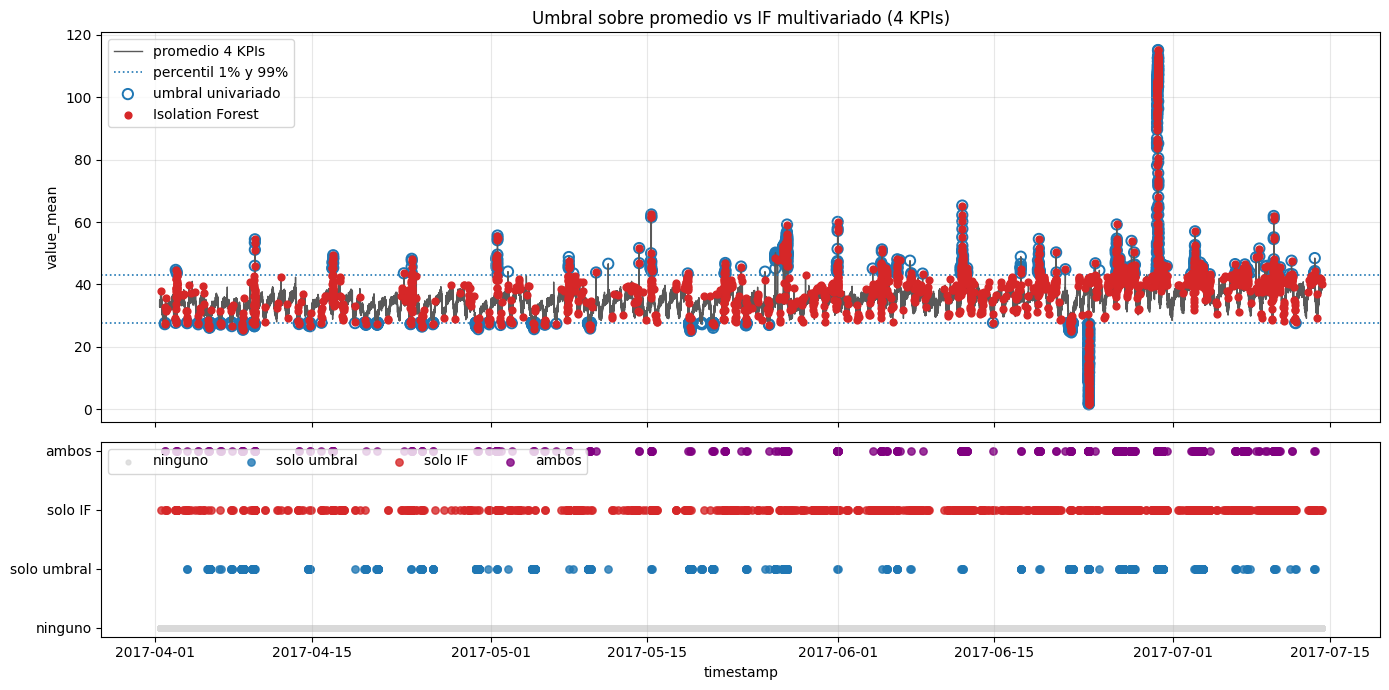

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(results["timestamp"], results["value_mean"], linewidth=1, color="0.35", label="promedio 4 KPIs")
axes[0].axhline(q_low, color="tab:blue", linestyle=":", linewidth=1.2)
axes[0].axhline(q_high, color="tab:blue", linestyle=":", linewidth=1.2, label="percentil 1% y 99%")
axes[0].scatter(
    results.loc[results["univariate_outlier"], "timestamp"],
    results.loc[results["univariate_outlier"], "value_mean"],
    s=55,
    facecolors="none",
    edgecolors="tab:blue",
    linewidths=1.4,
    label="umbral univariado",
)
axes[0].scatter(
    results.loc[results["is_anomaly"], "timestamp"],
    results.loc[results["is_anomaly"], "value_mean"],
    s=24,
    color="tab:red",
    label="Isolation Forest",
    zorder=3,
)
axes[0].set_title("Umbral sobre promedio vs IF multivariado (4 KPIs)")
axes[0].set_ylabel("value_mean")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

category = np.select(
    [
        results["univariate_outlier"] & results["is_anomaly"],
        results["is_anomaly"],
        results["univariate_outlier"],
    ],
    ["ambos", "solo IF", "solo umbral"],
    default="ninguno",
)
category_to_y = {"ninguno": 0, "solo umbral": 1, "solo IF": 2, "ambos": 3}
category_colors = {"ninguno": "0.85", "solo umbral": "tab:blue", "solo IF": "tab:red", "ambos": "purple"}

for cat, y in category_to_y.items():
    mask = category == cat
    axes[1].scatter(
        results.loc[mask, "timestamp"],
        np.full(mask.sum(), y),
        s=12 if cat == "ninguno" else 28,
        color=category_colors[cat],
        label=cat,
        alpha=0.8,
    )
axes[1].set_yticks(list(category_to_y.values()), list(category_to_y.keys()))
axes[1].set_xlabel("timestamp")
axes[1].legend(loc="upper left", ncol=4)
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Sensibilidad a `contamination`

Misma matriz `X_scaled`; solo cambia el corte del ranking.


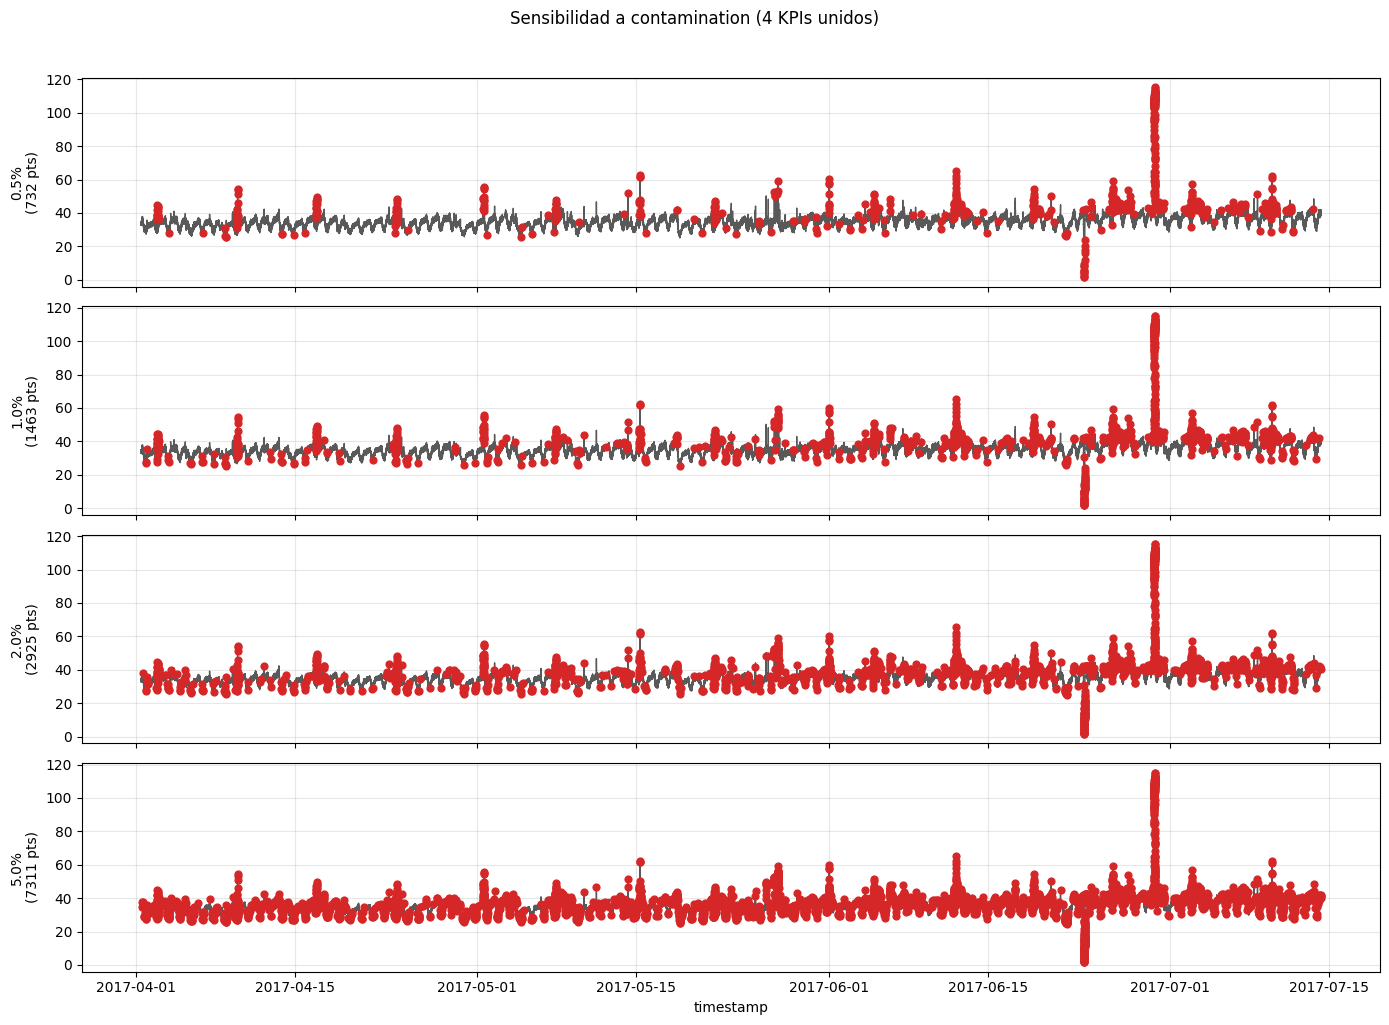

,contamination,n_anomalies
0,0.005,732
1,0.010,1463
2,0.020,2925
3,0.050,7311


In [15]:
contamination_values = [0.005, 0.01, 0.02, 0.05]
summary_rows = []

fig, axes = plt.subplots(len(contamination_values), 1, figsize=(14, 10), sharex=True, sharey=True)
fig.suptitle("Sensibilidad a contamination (4 KPIs unidos)", y=1.02)

for ax, cont in zip(axes, contamination_values):
    tmp_model = IsolationForest(
        n_estimators=m,
        max_samples=psi,
        contamination=cont,
        random_state=RANDOM_STATE,
    )
    tmp_pred = tmp_model.fit_predict(X_scaled) == -1
    n_tmp = int(tmp_pred.sum())
    summary_rows.append({"contamination": cont, "n_anomalies": n_tmp})

    ax.plot(results["timestamp"], results["value_mean"], linewidth=1, color="0.35")
    ax.scatter(
        results.loc[tmp_pred, "timestamp"],
        results.loc[tmp_pred, "value_mean"],
        color="tab:red",
        s=24,
        zorder=3,
    )
    ax.set_ylabel(f"{cont:.1%}\n({n_tmp} pts)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("timestamp")
plt.tight_layout()
plt.show()

pd.DataFrame(summary_rows)


## 12. Sensibilidad a $\psi$

Con `contamination` fijo, el **número** de anomalías no cambia; miramos overlap del top-30 y % de etiquetas distintas.


In [16]:
psi_values = [64, 128, 256, min(512, len(X_scaled))]
psi_rows = []
base_top_idx = set(results.sort_values("anomaly_score", ascending=False).head(30).index)
base_flags = results["is_anomaly"].to_numpy()
n_esperado = int(contamination * len(X_scaled))

for psi_candidate in psi_values:
    tmp_model = IsolationForest(
        n_estimators=m,
        max_samples=psi_candidate,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )
    tmp_pred = tmp_model.fit_predict(X_scaled) == -1
    tmp_score = -tmp_model.score_samples(X_scaled)
    tmp_top_idx = set(
        pd.Series(tmp_score, index=results.index)
        .sort_values(ascending=False)
        .head(30)
        .index
    )
    psi_rows.append({
        "psi": psi_candidate,
        "n_anomalies": int(tmp_pred.sum()),
        "n_esperado_por_cont": n_esperado,
        "overlap_top30_vs_base": len(base_top_idx & tmp_top_idx) / len(base_top_idx),
        "pct_etiquetas_distintas": float((tmp_pred != base_flags).mean()),
    })

pd.DataFrame(psi_rows)


,psi,n_anomalies,n_esperado_por_cont,overlap_top30_vs_base,pct_etiquetas_distintas
0,64,2925,2924,0.533333,0.011107
1,128,2925,2924,0.600000,0.008166
2,256,2925,2924,1.000000,0.000000
3,512,2925,2924,0.633333,0.007085


## 13. Sensibilidad a $m$

Más árboles suelen estabilizar el ranking; el costo de entrenamiento crece.


In [17]:
m_values = [1, 50, 500, 1500, 8000]
m_rows = []
base_top_idx = set(results.sort_values("anomaly_score", ascending=False).head(30).index)
base_flags = results["is_anomaly"].to_numpy()
n_esperado = int(contamination * len(X_scaled))

for m_candidate in m_values:
    tmp_model = IsolationForest(
        n_estimators=m_candidate,
        max_samples=psi,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )
    tmp_pred = tmp_model.fit_predict(X_scaled) == -1
    tmp_score = -tmp_model.score_samples(X_scaled)
    tmp_top_idx = set(
        pd.Series(tmp_score, index=results.index)
        .sort_values(ascending=False)
        .head(30)
        .index
    )
    m_rows.append({
        "m": m_candidate,
        "n_anomalies": int(tmp_pred.sum()),
        "n_esperado_por_cont": n_esperado,
        "overlap_top30_vs_base": len(base_top_idx & tmp_top_idx) / len(base_top_idx),
        "pct_etiquetas_distintas": float((tmp_pred != base_flags).mean()),
    })

pd.DataFrame(m_rows)


,m,n_anomalies,n_esperado_por_cont,overlap_top30_vs_base,pct_etiquetas_distintas
0,1,405,2924,0.033333,0.020011
1,50,2925,2924,0.466667,0.010040
2,500,2925,2924,0.766667,0.004897
3,1500,2925,2924,0.766667,0.005499
4,8000,2925,2924,0.733333,0.005471


## 14. Interpretar anomalías con features

Revisamos el top-10 con los valores de cada KPI y sus `rolling_z`.


In [18]:
display_cols = (
    ["timestamp", "anomaly_score", "is_anomaly"]
    + SHORT_NAMES
    + [f"{c}_rolling_z" for c in SHORT_NAMES]
)
results.sort_values("anomaly_score", ascending=False).head(10)[display_cols]


,timestamp,anomaly_score,is_anomaly,kpi_a,kpi_b,kpi_c,kpi_d,kpi_a_rolling_z,kpi_b_rolling_z,kpi_c_rolling_z,kpi_d_rolling_z
120740,2017-06-25 20:12:00,0.678442,True,37.26,61.83,65.02,36.06,2.365640,3.144543,3.143573,2.197747
126014,2017-06-29 15:09:00,0.674825,True,55.35,146.94,147.01,71.64,2.566163,-2.045753,-2.304554,-1.362721
126007,2017-06-29 15:02:00,0.670290,True,49.76,155.13,155.62,87.64,-1.088756,-2.198637,-2.397531,0.914505
126020,2017-06-29 15:16:00,0.669649,True,63.21,152.65,154.01,65.60,2.673088,0.480298,0.452513,-1.841894
101655,2017-06-12 03:06:00,0.666023,True,38.68,58.53,60.55,62.97,-0.764575,2.977881,2.989653,3.062298
126025,2017-06-29 15:21:00,0.662031,True,53.37,112.74,113.04,61.55,-0.577408,-2.754753,-2.695136,-1.410976
140322,2017-07-09 23:06:00,0.661665,True,38.08,78.59,79.30,48.54,-0.129153,1.470826,1.502104,3.080532
126026,2017-06-29 15:22:00,0.660020,True,51.93,95.90,95.07,59.90,-0.832477,-2.445576,-2.452368,-1.425127
126023,2017-06-29 15:19:00,0.655052,True,53.51,138.60,137.54,65.05,-0.392793,-2.672208,-2.687689,-1.257266
101656,2017-06-12 03:07:00,0.654945,True,36.07,92.85,93.29,38.93,-0.810753,2.944834,2.902236,-0.121282


## 15. Ejercicios para obligatorio — resueltos
El laboratorio de arriba usa **4 KPIs → 14 features**. En esta sección:

1. **Agregamos un 5º KPI** elegido del propio `kpi_summary` (el de mayor solape temporal con los 4 actuales) y medimos cómo cambia el join (ej. 1).
2. **Reconstruimos las features** con los 5 KPIs → **17 features** (ej. 2).
3. **Repetimos todos los experimentos** (las 3 configuraciones + sensibilidad a `contamination`, `ψ` y `m`) sobre la nueva matriz y comparamos contra el baseline de 4 KPIs.
4. **Reportamos qué cambia** (solape del join, número y cuáles anomalías, costo de alertas, por qué escalar) en la celda final (ej. 3 y 4).

In [19]:
# Ej. 1 -- Elegir un 5º KPI del propio kpi_summary (el de mayor solape temporal con los 4 actuales)
usados = set(KPI_IDS)
ts_base = set(raw["timestamp"])  # minutos del join de 4 KPIs

candidatos = kpi_summary[~kpi_summary.index.isin(usados)].sort_values("puntos", ascending=False)
filas = []
for cand_id in candidatos.head(12).index:
    ts_cand = set(kpi_all.loc[kpi_all["KPI ID"] == cand_id, "timestamp"])
    filas.append({
        "KPI ID": cand_id,
        "puntos": int(candidatos.loc[cand_id, "puntos"]),
        "overlap_con_join_4kpi": len(ts_base & ts_cand),
    })
overlap_tbl = (
    pd.DataFrame(filas)
    .sort_values(["overlap_con_join_4kpi", "puntos"], ascending=False)
    .reset_index(drop=True)
)
KPI_E = overlap_tbl.iloc[0]["KPI ID"]
print("Candidatos a 5º KPI (por solape temporal con el join de 4):")
display(overlap_tbl)
print("5º KPI elegido:", KPI_E)

# Join de los 5 KPIs (mismo pivot + dropna que el laboratorio)
KPI_IDS_5 = KPI_IDS + [KPI_E]
SHORT_NAMES_5 = SHORT_NAMES + ["kpi_e"]
ID_TO_SHORT_5 = dict(zip(KPI_IDS_5, SHORT_NAMES_5))

subset5 = kpi_all[kpi_all["KPI ID"].isin(KPI_IDS_5)].copy()
raw5 = (
    subset5.pivot(index="timestamp", columns="KPI ID", values="value")
    .sort_index()
    .rename(columns=ID_TO_SHORT_5)
    .reset_index()
    .dropna()
    .reset_index(drop=True)
)

print(f"\nFilas join 4 KPIs: {len(raw):>8,}")
print(f"Filas join 5 KPIs: {len(raw5):>8,}   (perdidas al sumar el 5º KPI: {len(raw) - len(raw5):,})")
print(f"Ventana 5 KPIs: {raw5['timestamp'].min()}  ->  {raw5['timestamp'].max()}")
raw5[SHORT_NAMES_5].describe().T

Candidatos a 5º KPI (por solape temporal con el join de 4):


,KPI ID,puntos,overlap_con_join_4kpi
0,42d6616d-c9c5-370a-a8ba-17ead74f3114,146253,146252
1,8723f0fb-eaef-32e6-b372-6034c9c04b80,146243,146241
2,6d1114ae-be04-3c46-b5aa-be1a003a57cd,146239,146237
3,847e8ecc-f8d2-3a93-9107-f367a0aab37d,146228,146226
4,55f8b8b8-b659-38df-b3df-e4a5a8a54bc9,146204,146203
5,ba5f3328-9f3f-3ff5-a683-84437d16d554,146126,146125
6,6efa3a07-4544-34a0-b921-a155bd1a05e8,145135,145133
7,431a8542-c468-3988-a508-3afd06a218da,129046,101792
8,6a757df4-95e5-3357-8406-165e2bd49360,129010,101780
9,7103fa0f-cac4-314f-addc-866190247439,128992,101756


5º KPI elegido: 42d6616d-c9c5-370a-a8ba-17ead74f3114



Filas join 4 KPIs:  146,253
Filas join 5 KPIs:  146,252   (perdidas al sumar el 5º KPI: 1)
Ventana 5 KPIs: 2017-04-01 10:08:00  ->  2017-07-14 06:14:00


,count,mean,std,min,25%,50%,75%,max
KPI ID,,,,,,,,
kpi_a,146252.0,34.438900,4.203551,0.0,31.55,34.15,36.84,98.33
kpi_b,146252.0,35.048629,5.692118,1.5,32.11,34.80,37.40,172.19
kpi_c,146252.0,35.539480,5.729480,1.7,32.59,35.30,37.95,172.42
kpi_d,146252.0,34.188622,5.287176,0.0,31.37,34.02,36.69,119.77
kpi_e,146252.0,34.065780,5.377371,0.0,31.22,33.97,36.64,128.80


In [20]:
# Reconstruir features con 5 KPIs (reusa el helper build_features_multikpi) -> 5*3 + 2 = 17 features
features5 = build_features_multikpi(raw5, SHORT_NAMES_5, window=12)

feature_cols5 = []
for c in SHORT_NAMES_5:
    feature_cols5 += [c, f"{c}_diff_1", f"{c}_rolling_z"]
feature_cols5 += ["hour", "dayofweek"]

X5 = features5[feature_cols5]
scaler5 = StandardScaler()
X5_scaled = scaler5.fit_transform(X5)

print(f"Features 4 KPIs: {len(feature_cols)}  ->  Features 5 KPIs: {len(feature_cols5)}  (5*3 + 2 = {5*3 + 2})")
print(f"Filas para entrenar: {X5.shape[0]:,}")
features5.head()

Features 4 KPIs: 14  ->  Features 5 KPIs: 17  (5*3 + 2 = 17)
Filas para entrenar: 146,217


,timestamp,kpi_a,kpi_a_diff_1,kpi_a_rolling_z,kpi_b,kpi_b_diff_1,kpi_b_rolling_z,kpi_c,kpi_c_diff_1,kpi_c_rolling_z,kpi_d,kpi_d_diff_1,kpi_d_rolling_z,kpi_e,kpi_e_diff_1,kpi_e_rolling_z,hour,dayofweek
0,2017-04-01 10:10:00,32.79,-3.81,-1.053203,33.06,0.86,0.992339,31.82,-0.43,-0.810026,34.40,1.41,0.359050,34.34,-1.33,-1.048285,10,5
1,2017-04-01 10:11:00,34.28,1.49,-0.249142,32.35,-0.71,0.169385,32.94,1.12,0.437932,33.53,-0.87,-0.486341,36.54,2.20,1.213283,10,5
2,2017-04-01 10:12:00,34.69,0.41,0.008740,32.69,0.34,0.560960,33.20,0.26,0.678454,35.45,1.92,1.240136,36.06,-0.48,0.604749,10,5
3,2017-04-01 10:13:00,35.30,0.61,0.413320,32.27,-0.42,-0.070585,32.70,-0.50,-0.049029,32.96,-2.49,-1.038737,37.14,1.08,1.325396,10,5
4,2017-04-01 10:14:00,35.25,-0.05,0.346534,32.77,0.50,0.694057,32.55,-0.15,-0.274189,33.44,0.48,-0.519478,35.64,-1.50,-0.158680,10,5


In [21]:
# Repetir el experimento de las 3 configuraciones, ahora con 17 features (reusa fit_isolation_forest)
psi5 = min(256, len(features5))

models5 = {}
for cfg in MODEL_CONFIGS:
    _, scores, flags = fit_isolation_forest(X5_scaled, cfg["m"], psi5, cfg["contamination"])
    models5[cfg["name"]] = {"label": cfg["label"], "anomaly_score": scores, "is_anomaly": flags}

results5 = features5.copy()
results5["anomaly_score"] = models5["base"]["anomaly_score"]
results5["is_anomaly"] = models5["base"]["is_anomaly"]
results5["value_mean"] = results5[SHORT_NAMES_5].mean(axis=1)

base5_flags = models5["base"]["is_anomaly"]
rows5 = []
for cfg in MODEL_CONFIGS:
    flags = models5[cfg["name"]]["is_anomaly"]
    rows5.append({
        "config": cfg["name"],
        "m": cfg["m"],
        "contamination": cfg["contamination"],
        "n_anomalias_5kpi": int(flags.sum()),
        "overlap_con_base_5kpi": int((flags & base5_flags).sum()),
        "pct_etiquetas_distintas": round(100 * (flags != base5_flags).mean(), 2),
    })
pd.DataFrame(rows5)

,config,m,contamination,n_anomalias_5kpi,overlap_con_base_5kpi,pct_etiquetas_distintas
0,base,200,0.020,2925,2925,0.00
1,pocas_alertas,200,0.005,732,732,1.50
2,pocos_arboles,50,0.020,2925,2209,0.98


In [22]:
# ¿Qué anomalías cambian al pasar de 4 a 5 KPIs? (comparación por timestamp, config 'base')
anom_ts_4 = set(results.loc[results["is_anomaly"], "timestamp"])
anom_ts_5 = set(results5.loc[results5["is_anomaly"], "timestamp"])

comunes = anom_ts_4 & anom_ts_5
solo_4 = anom_ts_4 - anom_ts_5
solo_5 = anom_ts_5 - anom_ts_4

print(f"Anomalías base con 4 KPIs : {len(anom_ts_4)}")
print(f"Anomalías base con 5 KPIs : {len(anom_ts_5)}")
print(f"  detectadas por ambos    : {len(comunes)}")
print(f"  solo con 4 KPIs         : {len(solo_4)}  (dejaron de marcarse)")
print(f"  nuevas con el 5º KPI    : {len(solo_5)}  (aparecen por la dim. extra)")
print(f"  estabilidad (Jaccard)   : {len(comunes) / len(anom_ts_4 | anom_ts_5):.2%}")

Anomalías base con 4 KPIs : 2925
Anomalías base con 5 KPIs : 2925
  detectadas por ambos    : 2040
  solo con 4 KPIs         : 885  (dejaron de marcarse)
  nuevas con el 5º KPI    : 885  (aparecen por la dim. extra)
  estabilidad (Jaccard)   : 53.54%


In [23]:
# Repetir los barridos de sensibilidad sobre la matriz de 5 KPIs (17 features)
m5 = MODEL_CONFIGS[0]["m"]              # 200
cont5 = MODEL_CONFIGS[0]["contamination"]  # 0.02
base5_top30 = set(
    pd.Series(models5["base"]["anomaly_score"], index=results5.index)
    .sort_values(ascending=False).head(30).index
)

# (a) contamination: cambia CUÁNTAS anomalías
cont_rows = []
for cont in [0.005, 0.01, 0.02, 0.05]:
    pred = IsolationForest(n_estimators=m5, max_samples=psi5,
                           contamination=cont, random_state=RANDOM_STATE).fit_predict(X5_scaled) == -1
    cont_rows.append({"contamination": cont, "n_anomalias": int(pred.sum())})

# (b) psi (max_samples): con contamination fijo, miramos overlap del top-30
psi_rows = []
for psi_c in [64, 128, 256, min(512, len(X5_scaled))]:
    mdl = IsolationForest(n_estimators=m5, max_samples=psi_c,
                          contamination=cont5, random_state=RANDOM_STATE)
    mdl.fit(X5_scaled)
    top = set(pd.Series(-mdl.score_samples(X5_scaled), index=results5.index)
              .sort_values(ascending=False).head(30).index)
    psi_rows.append({"psi": psi_c, "overlap_top30_vs_base": round(len(base5_top30 & top) / 30, 3)})

# (c) m (n_estimators): más árboles estabilizan el ranking
m_rows = []
for m_c in [1, 50, 200, 500, 1500]:
    mdl = IsolationForest(n_estimators=m_c, max_samples=psi5,
                          contamination=cont5, random_state=RANDOM_STATE)
    mdl.fit(X5_scaled)
    top = set(pd.Series(-mdl.score_samples(X5_scaled), index=results5.index)
              .sort_values(ascending=False).head(30).index)
    m_rows.append({"m": m_c, "overlap_top30_vs_base": round(len(base5_top30 & top) / 30, 3)})

print("Sensibilidad a contamination (5 KPIs):")
display(pd.DataFrame(cont_rows))
print("Sensibilidad a psi / max_samples (5 KPIs):")
display(pd.DataFrame(psi_rows))
print("Sensibilidad a m / n_estimators (5 KPIs):")
display(pd.DataFrame(m_rows))

Sensibilidad a contamination (5 KPIs):


,contamination,n_anomalias
0,0.005,732
1,0.010,1463
2,0.020,2925
3,0.050,7311


Sensibilidad a psi / max_samples (5 KPIs):


,psi,overlap_top30_vs_base
0,64,0.667
1,128,0.767
2,256,1.000
3,512,0.700


Sensibilidad a m / n_estimators (5 KPIs):


,m,overlap_top30_vs_base
0,1,0.000
1,50,0.433
2,200,1.000
3,500,0.900
4,1500,0.833


In [24]:
# Ranking top-10 con 5 KPIs: marcamos cuáles son NUEVAS respecto al modelo de 4 KPIs
top5 = results5.sort_values("anomaly_score", ascending=False).head(10).copy()
top5["nueva_por_5to_kpi"] = ~top5["timestamp"].isin(anom_ts_4)

cols_rank = (
    ["timestamp", "anomaly_score", "nueva_por_5to_kpi"]
    + SHORT_NAMES_5
    + ["kpi_e_rolling_z"]
)
top5[cols_rank]

,timestamp,anomaly_score,nueva_por_5to_kpi,kpi_a,kpi_b,kpi_c,kpi_d,kpi_e,kpi_e_rolling_z
101655,2017-06-12 03:06:00,0.703375,False,38.68,58.53,60.55,62.97,57.70,3.098154
126014,2017-06-29 15:09:00,0.680361,False,55.35,146.94,147.01,71.64,75.06,-1.137335
126007,2017-06-29 15:02:00,0.678830,False,49.76,155.13,155.62,87.64,87.28,0.842408
126020,2017-06-29 15:16:00,0.678560,False,63.21,152.65,154.01,65.60,66.86,-2.011817
140321,2017-07-09 23:06:00,0.675197,False,38.08,78.59,79.30,48.54,50.77,3.007707
126002,2017-06-29 14:56:00,0.674863,False,51.55,157.72,159.11,91.63,91.23,1.940362
120740,2017-06-25 20:12:00,0.672044,False,37.26,61.83,65.02,36.06,40.74,2.113906
126025,2017-06-29 15:21:00,0.665466,False,53.37,112.74,113.04,61.55,61.79,-1.441764
125997,2017-06-29 14:51:00,0.661806,False,50.17,161.96,162.98,75.11,75.35,2.181896
126024,2017-06-29 15:20:00,0.661422,False,55.78,134.59,133.44,61.55,60.97,-1.761378


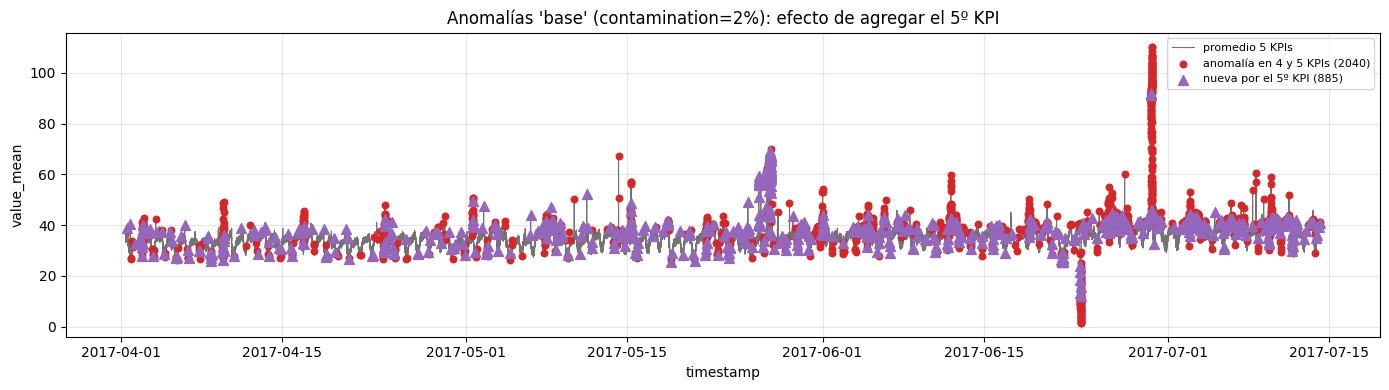

In [25]:
# Efecto visual del 5º KPI sobre las anomalías 'base'
nuevas_df = results5[results5["timestamp"].isin(solo_5)]
comunes_df = results5[results5["timestamp"].isin(comunes)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(results5["timestamp"], results5["value_mean"], color="0.45", linewidth=0.8, label="promedio 5 KPIs")
ax.scatter(comunes_df["timestamp"], comunes_df["value_mean"],
           s=22, color="tab:red", zorder=3, label=f"anomalía en 4 y 5 KPIs ({len(comunes)})")
ax.scatter(nuevas_df["timestamp"], nuevas_df["value_mean"],
           s=50, marker="^", color="tab:purple", zorder=4, label=f"nueva por el 5º KPI ({len(solo_5)})")
ax.set_title("Anomalías 'base' (contamination=2%): efecto de agregar el 5º KPI")
ax.set_xlabel("timestamp"); ax.set_ylabel("value_mean")
ax.legend(loc="upper right", fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Reporte: ¿qué pasó al agregar el 5º KPI?

**Ej. 1 — Solape temporal del join.** El join es un *inner join* (`pivot` + `dropna`): solo sobreviven los minutos presentes en **todos** los KPIs. Al sumar un 5º KPI con cobertura temporal distinta, el join solo puede **mantener o reducir** las filas, nunca aumentarlas (ver el conteo "Filas join 4 KPIs" vs "5 KPIs" arriba). Elegimos el candidato con **mayor solape** justamente para perder lo mínimo; un KPI de otra época habría vaciado el join.

**Ej. 2 — Cantidad de features.** Cada KPI aporta 3 columnas (`value`, `diff_1`, `rolling_z`) y hay 2 features temporales compartidas (`hour`, `dayofweek`):

$$ 4\times 3 + 2 = 14 \quad\longrightarrow\quad 5\times 3 + 2 = \mathbf{17} $$

El espacio donde el Isolation Forest aísla puntos pasa de 14 a 17 dimensiones. Las anomalías ahora también pueden venir de **combinaciones raras que involucran al 5º KPI** (ver "nuevas por 5º KPI" en el ranking y el gráfico).

**Qué cambió en los resultados.** Con `contamination` fijo, el **número** de anomalías casi no cambia (es ~2% de las filas), pero **cuáles** se marcan sí cambia: aparecen anomalías nuevas dominadas por el `rolling_z` del 5º KPI y desaparecen algunas que en 4D eran límites. El barrido de `m`/`ψ` muestra la misma tendencia que con 4 KPIs: más árboles estabilizan el ranking (mayor overlap del top-30) y `ψ` afecta poco con `contamination` fijo.

**Ej. 3 — `contamination` 0.01 vs 0.05 con revisión manual de un SRE.** `contamination` es el % de filas etiquetadas como anomalía. Pasar de 1% a 5% **quintuplica** la cola de alertas: sobre ~140k minutos son ~1.4k vs ~7k alertas. Si cada alerta cuesta revisión humana, 0.05 es operativamente inviable y se llena de falsos positivos; 0.01 prioriza precisión (menos alertas, las más aisladas) a riesgo de perder anomalías sutiles. Para un SRE conviene **0.01 (o menos) + ranking por `anomaly_score`** y revisar de arriba hacia abajo según capacidad.

**Ej. 4 — Por qué escalar antes de mezclar KPIs.** Los KPIs vienen en escalas arbitrarias (el CSV no trae unidades) y mezclamos `value` con `diff_1`, `rolling_z`, `hour`, `dayofweek`, todas con magnitudes muy distintas. Aunque el Isolation Forest usa cortes *axis-aligned* (es menos sensible a la escala que SVM o métodos basados en distancia), al muestrear cortes y al promediar profundidad de aislamiento una feature de rango enorme **domina** el ranking y opaca a las demás. `StandardScaler` lleva todo a desvíos estándar comparables, de modo que cada KPI y cada tipo de feature contribuyen de forma equilibrada a la decisión.